# RCC Subtyping — Step 3: CLAM-SB / CLAM-MB Training
### BME 515 Final Project (Person 3)
Train CLAM single-branch (SB) and multi-branch (MB) on the 2048-dim ResNet50 features produced in Step 2.

Classes: Benign, Chromophobe (KICH), Clearcell (ccRCC), Oncocytoma, Papillary (KIRP) — 5-way slide-level classification.

## 0) Setup and Environment
This cell imports all required libraries, sets project paths, creates output folders, fixes random seeds for reproducibility, and selects the compute device (MPS, CUDA, or CPU).

Expected output: the selected device printed to confirm where training/inference will run.

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt

BASE_DIR   = Path(r'C:\Users\raphi\Documents\BME515-RCC-Classification')
FEATURE_DIR = BASE_DIR / 'features' / 'features'
META_PATH  = BASE_DIR / 'MetaData_Release_1.1.csv'
CKPT_DIR   = BASE_DIR / 'checkpoints'
RESULT_DIR = BASE_DIR / 'results'
CKPT_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [2]:
import torch
print('torch:', torch.__version__)
print('cuda build:', torch.version.cuda)
print('available:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')
x = torch.randn(1000, 1000).cuda()
y = x @ x
print('GPU compute works:', y.shape, y.device)

torch: 2.12.0.dev20260408+cu128
cuda build: 12.8
available: True
device: NVIDIA GeForce RTX 5060 Laptop GPU
GPU compute works: torch.Size([1000, 1000]) cuda:0


### 1. Build label table

In [3]:
CLASSES = ['Benign', 'Chromophobe', 'Clearcell', 'Oncocytoma', 'Papillary']
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}
N_CLASSES = len(CLASSES)

meta = pd.read_csv(META_PATH)
meta['slide_id'] = meta['File Name'].str.replace('.png', '', regex=False)

available = sorted(p.stem for p in FEATURE_DIR.glob('*.h5'))
df = meta[meta['slide_id'].isin(available)].copy()
df['label'] = df['Diagnosis'].map(label2idx)
df = df.dropna(subset=['label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)

print(f'usable slides: {len(df)}')
print(df['Diagnosis'].value_counts())

usable slides: 484
Diagnosis
Clearcell      310
Papillary       80
Oncocytoma      42
Benign          29
Chromophobe     23
Name: count, dtype: int64


## 1.1) Data Integrity Checks
This block prints metadata schema and feature-file stats to verify that metadata IDs align with available feature files.

Use it to diagnose path problems, naming mismatches, or missing features before training.

In [4]:
# Check metadata
print('=== Metadata ===')
print('rows:', len(meta))
print('columns:', list(meta.columns))
print('first 3 File Names:', meta['File Name'].head(3).tolist())
print('first 3 slide_ids:', meta['slide_id'].head(3).tolist())

# Check feature files
print('\n=== Feature files ===')
print('FEATURE_DIR:', FEATURE_DIR)
print('exists:', FEATURE_DIR.exists())
h5_files = list(FEATURE_DIR.glob('*.h5'))
print('number of .h5 files:', len(h5_files))
if h5_files:
    print('first 3 .h5 filenames:', [p.name for p in h5_files[:3]])
    print('first 3 .h5 stems:', [p.stem for p in h5_files[:3]])

=== Metadata ===
rows: 563
columns: ['File Name', 'Diagnosis', 'Slide Type', 'Data Split', 'slide_id']
first 3 File Names: ['DHMC_0001.png', 'DHMC_0002.png', 'DHMC_0003.png']
first 3 slide_ids: ['DHMC_0001', 'DHMC_0002', 'DHMC_0003']

=== Feature files ===
FEATURE_DIR: C:\Users\raphi\Documents\BME515-RCC-Classification\features\features
exists: True
number of .h5 files: 484
first 3 .h5 filenames: ['DHMC_0001.h5', 'DHMC_0002.h5', 'DHMC_0003.h5']
first 3 .h5 stems: ['DHMC_0001', 'DHMC_0002', 'DHMC_0003']


## 2) Dataset Class (Slide-Level Bags)
Defines a PyTorch Dataset where each sample is one slide represented by a variable-length bag of patch features.

Returns per item:
1. Feature tensor with shape [N, 2048] (or reshaped equivalent).
2. Integer class label.
3. Slide ID string.

Note: this loader currently reads `.pt` files inside the class body. If your final pipeline uses `.h5`, this cell should be updated accordingly.

In [5]:
class SlideFeatureDataset(Dataset):
    """One item = one slide. Returns (features [N,2048], label int, slide_id)."""
    def __init__(self, df, feature_dir):
        self.df = df.reset_index(drop=True)
        self.feature_dir = Path(feature_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        h5_path = self.feature_dir / f"{row.slide_id}.h5"

        if not h5_path.exists():
            raise FileNotFoundError(f"Missing feature file: {h5_path}")

        with h5py.File(h5_path, "r") as f:
            # common dataset keys used in feature files
            for k in ["features", "feats", "x", "embeddings"]:
                if k in f:
                    arr = f[k][:]
                    break
            else:
                keys = list(f.keys())
                if len(keys) == 1:
                    arr = f[keys[0]][:]
                else:
                    raise KeyError(f"No feature dataset key found in {h5_path}. Keys: {keys}")

        feats = torch.from_numpy(np.asarray(arr))
        if feats.ndim == 3:
             feats = feats.view(feats.size(0), -1)
        elif feats.ndim != 2:
            feats = feats.reshape(feats.shape[0], -1)

        return feats.float(), int(row.label), row.slide_id

## 3) Stratified Data Split and Dataset Objects
Splits data into train/validation/test sets with label stratification to preserve class balance across splits.

It also saves split CSV files for reproducibility and instantiates PyTorch Dataset objects for each split.

Expected output: sample counts and class distributions for train/val/test.

In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30,
                                     stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50,
                                   stratify=temp_df['label'], random_state=SEED)

print(f'train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}')
for name, sub in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}:', dict(sub['Diagnosis'].value_counts()))

for name, sub in [('train', train_df), ('val', val_df), ('test', test_df)]:
    sub[['slide_id','Diagnosis','label']].to_csv(RESULT_DIR / f'split_{name}.csv', index=False)

train_ds = SlideFeatureDataset(train_df, FEATURE_DIR)
val_ds   = SlideFeatureDataset(val_df,   FEATURE_DIR)
test_ds  = SlideFeatureDataset(test_df,  FEATURE_DIR)

train: 338  val: 73  test: 73
  train: {'Clearcell': np.int64(217), 'Papillary': np.int64(56), 'Oncocytoma': np.int64(29), 'Benign': np.int64(20), 'Chromophobe': np.int64(16)}
  val: {'Clearcell': np.int64(46), 'Papillary': np.int64(12), 'Oncocytoma': np.int64(7), 'Chromophobe': np.int64(4), 'Benign': np.int64(4)}
  test: {'Clearcell': np.int64(47), 'Papillary': np.int64(12), 'Oncocytoma': np.int64(6), 'Benign': np.int64(5), 'Chromophobe': np.int64(3)}


## 4) CLAM Model Architecture (Gated Attention + SB/MB)
This block defines the core neural network used for slide-level RCC subtype prediction.

Components:
1. `GatedAttention`: computes attention scores over patch embeddings using tanh-sigmoid gating.
2. `CLAM`: unified implementation for single-branch (SB) and multi-branch (MB) modes.
3. Instance-level heads: support clustering-style supervision via top-k and bottom-k patch sampling.

Forward-pass flow:
1. Project patch features from 2048 to hidden dimension.
2. Compute attention scores across patches.
3. Normalize attention with softmax.
4. Aggregate patch features into slide representation.
5. Predict slide-level class probabilities.
6. Optionally compute instance-level loss during training.

Outputs from `forward(...)`:
1. `logits`: raw class scores for the slide.
2. `y_prob`: softmax probabilities.
3. `y_hat`: predicted class index.
4. `A_raw`: pre-softmax attention scores.
5. `inst_loss`: instance-level auxiliary loss.

In [7]:
class GatedAttention(nn.Module):
    """Gated attention from Ilse et al. 2018 / CLAM."""
    def __init__(self, in_dim, hidden=256, n_branches=1, dropout=0.25):
        super().__init__()
        self.attn_a = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(), nn.Dropout(dropout))
        self.attn_b = nn.Sequential(nn.Linear(in_dim, hidden), nn.Sigmoid(), nn.Dropout(dropout))
        self.attn_c = nn.Linear(hidden, n_branches)

    def forward(self, h):
        # h: [N, D]
        a = self.attn_a(h) * self.attn_b(h)        # [N, hidden]
        return self.attn_c(a)                      # [N, n_branches]


class CLAM(nn.Module):
    """Unified CLAM module supporting SB (n_branches=1) and MB (n_branches=n_classes)."""
    def __init__(self, in_dim=2048, hidden=512, attn_hidden=256,
                 n_classes=5, k_sample=8, multi_branch=False, dropout=0.25):
        super().__init__()
        self.n_classes = n_classes
        self.k_sample = k_sample
        self.multi_branch = multi_branch
        n_branches = n_classes if multi_branch else 1

        # patch-level projection
        self.fc = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))

        self.attention = GatedAttention(hidden, attn_hidden, n_branches, dropout)

        # slide classifier
        if multi_branch:
            # one classifier head per class (binary: class vs not-class)
            self.classifiers = nn.ModuleList([nn.Linear(hidden, 1) for _ in range(n_classes)])
        else:
            self.classifier = nn.Linear(hidden, n_classes)

        # instance classifiers for clustering loss (one per class)
        self.instance_classifiers = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_classes)])

    # --- clustering / instance helpers -----------------------------------
    @staticmethod
    def _create_labels(length, value, device):
        return torch.full((length,), value, dtype=torch.long, device=device)

    def _inst_eval(self, attn_scores, h, classifier):
        """Attend-class: top-k positives, bottom-k negatives."""
        k = min(self.k_sample, h.size(0) // 2)
        if k < 1: return None, None
        top_p_ids = torch.topk(attn_scores, k)[1]
        top_n_ids = torch.topk(-attn_scores, k)[1]
        top_p = h[top_p_ids]
        top_n = h[top_n_ids]
        p_labels = self._create_labels(k, 1, h.device)
        n_labels = self._create_labels(k, 0, h.device)
        all_inst = torch.cat([top_p, top_n], dim=0)
        all_lbl  = torch.cat([p_labels, n_labels], dim=0)
        logits = classifier(all_inst)
        return logits, all_lbl

    def _inst_eval_out(self, attn_scores, h, classifier):
        """Non-attend-class: top-k are pseudo-negatives."""
        k = min(self.k_sample, h.size(0) // 2)
        if k < 1: return None, None
        top_p_ids = torch.topk(attn_scores, k)[1]
        top_p = h[top_p_ids]
        p_labels = self._create_labels(k, 0, h.device)
        logits = classifier(top_p)
        return logits, p_labels

    # --- forward ----------------------------------------------------------
    def forward(self, h, label=None, instance_eval=True):
        # h: [N, in_dim]
        h = self.fc(h)                             # [N, hidden]
        A = self.attention(h)                      # [N, n_branches]
        A = torch.transpose(A, 1, 0)               # [n_branches, N]
        A_raw = A
        A = F.softmax(A, dim=1)                    # softmax over patches

        # instance-level clustering loss (training only, if label provided)
        inst_loss = torch.tensor(0., device=h.device)
        inst_count = 0
        if instance_eval and label is not None:
            onehot = F.one_hot(torch.tensor(label, device=h.device),
                               num_classes=self.n_classes).long()
            # for SB we only have 1 attention branch → use it for class=label
            for c in range(self.n_classes):
                scores = A[c if self.multi_branch else 0]
                cls = self.instance_classifiers[c]
                if onehot[c] == 1:
                    logits, lbl = self._inst_eval(scores, h, cls)
                else:
                    if not self.multi_branch:
                        continue  # SB only runs out-of-class sampling when MB
                    logits, lbl = self._inst_eval_out(scores, h, cls)
                if logits is None: continue
                inst_loss = inst_loss + F.cross_entropy(logits, lbl)
                inst_count += 1
            if inst_count > 0:
                inst_loss = inst_loss / inst_count

        # slide-level aggregation
        if self.multi_branch:
            # M: [n_classes, hidden] — one embedding per class
            M = A @ h                              # [n_classes, hidden]
            logits = torch.cat([self.classifiers[c](M[c:c+1])
                                for c in range(self.n_classes)], dim=1)  # [1, n_classes]
        else:
            M = A @ h                              # [1, hidden]
            logits = self.classifier(M)            # [1, n_classes]

        y_prob = F.softmax(logits, dim=1)
        y_hat  = torch.argmax(logits, dim=1)
        return logits, y_prob, y_hat, A_raw, inst_loss

## 5) Loss, Collation, and Evaluation Utilities
Defines utility functions used during optimization and validation/testing:
1. `mil_collate`: custom collate function for variable-length slide bags.
2. `compute_class_weights`: inverse-frequency class weighting for cross-entropy.
3. `evaluate`: computes loss, accuracy, macro-F1, and stores predictions/probabilities.

These utilities ensure stable mini-batch handling and consistent metric tracking across splits.

In [8]:
def compute_class_weights(df, n_classes):
    counts = np.zeros(n_classes)
    for lab in df['label'].values:
        counts[int(lab)] += 1
    # inverse frequency, normalized
    w = counts.sum() / (n_classes * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32)

class_weights = compute_class_weights(train_df, N_CLASSES).to(device)
print('class weights:', dict(zip(CLASSES, class_weights.cpu().numpy().round(3))))

class weights: {'Benign': np.float32(3.38), 'Chromophobe': np.float32(4.225), 'Clearcell': np.float32(0.312), 'Oncocytoma': np.float32(2.331), 'Papillary': np.float32(1.207)}


## 6) Training Configuration and Loop
Sets training hyperparameters and trains both CLAM variants with early stopping on validation macro-F1.

Training behavior:
1. Builds model, optimizer, and weighted CE loss.
2. Combines bag-level and instance-level losses (`total = bag + lambda_inst * inst`).
3. Saves the best checkpoint for each model to `checkpoints/`.
4. Logs per-epoch metrics to `results/*_history.csv`.

In [9]:
def train_one_epoch(model, loader, optimizer, ce_loss, bag_weight=0.7):
    model.train()
    total_loss, total_bag, total_inst, correct, n = 0, 0, 0, 0, 0
    for feats, label, _ in loader:
        feats = feats.squeeze(0).to(device)
        label_t = torch.tensor([label], dtype=torch.long, device=device) \
                  if not torch.is_tensor(label) else label.to(device)
        optimizer.zero_grad()
        logits, _, y_hat, _, inst_loss = model(feats, label=int(label_t.item()),
                                                instance_eval=True)
        bag_loss = ce_loss(logits, label_t)
        loss = bag_weight * bag_loss + (1 - bag_weight) * inst_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item(); total_bag += bag_loss.item()
        total_inst += float(inst_loss.item() if torch.is_tensor(inst_loss) else inst_loss)
        correct += (y_hat.item() == int(label_t.item()))
        n += 1
    return total_loss/n, total_bag/n, total_inst/n, correct/n

@torch.no_grad()
def evaluate(model, loader, ce_loss):
    model.eval()
    y_true, y_pred, y_prob, slide_ids = [], [], [], []
    total_loss, n = 0, 0
    for feats, label, sid in loader:
        feats = feats.squeeze(0).to(device)
        label_t = torch.tensor([label], dtype=torch.long, device=device) \
                  if not torch.is_tensor(label) else label.to(device)
        logits, prob, y_hat, _, _ = model(feats, label=None, instance_eval=False)
        loss = ce_loss(logits, label_t)
        total_loss += loss.item(); n += 1
        y_true.append(int(label_t.item()))
        y_pred.append(int(y_hat.item()))
        y_prob.append(prob.cpu().numpy().ravel())
        slide_ids.append(sid[0] if isinstance(sid, (list, tuple)) else sid)
    y_prob = np.stack(y_prob, axis=0)
    return {
        'loss': total_loss/n,
        'acc': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
        'slide_ids': slide_ids
    }

### 6.1) Launch SB and MB Training Runs
Executes the training loop for:
1. `clam_sb` (single-branch CLAM).
2. `clam_mb` (multi-branch CLAM).

Expected output: epoch-by-epoch train/validation metrics and saved best checkpoints.

In [10]:
def run_training(model_name, multi_branch, epochs=50, lr=2e-4, wd=1e-5,
                 bag_weight=0.7, patience=10):
    print(f'\n=== Training {model_name} ===')
    model = CLAM(in_dim=2048, hidden=512, attn_hidden=256,
                 n_classes=N_CLASSES, k_sample=8,
                 multi_branch=multi_branch).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce = nn.CrossEntropyLoss(weight=class_weights)

    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)

    history = []
    best_val_f1, best_epoch, bad = -1, 0, 0
    best_path = CKPT_DIR / f'{model_name}_best.pt'

    for ep in range(1, epochs+1):
        tr_loss, tr_bag, tr_inst, tr_acc = train_one_epoch(model, train_loader, opt, ce, bag_weight)
        val = evaluate(model, val_loader, ce)
        sched.step()

        history.append({
            'epoch': ep,
            'train_loss': tr_loss,
            'train_bag_loss': tr_bag,
            'train_inst_loss': tr_inst,
            'train_acc': tr_acc,
            'val_loss': val['loss'],
            'val_acc': val['acc'],
            'val_f1': val['f1_macro']
        })

        print(f'[{model_name}] ep {ep:02d} | '
              f'train loss {tr_loss:.3f} (bag {tr_bag:.3f}, inst {tr_inst:.3f}) acc {tr_acc:.3f} | '
              f'val loss {val["loss"]:.3f} acc {val["acc"]:.3f} f1 {val["f1_macro"]:.3f}')

        if val['f1_macro'] > best_val_f1:
            best_val_f1, best_epoch, bad = val['f1_macro'], ep, 0
            torch.save(model.state_dict(), best_path)
        else:
            bad += 1
            if bad >= patience:
                print(f'early stop at ep {ep} (best ep {best_epoch}, val f1 {best_val_f1:.3f})')
                break

    pd.DataFrame(history).to_csv(RESULT_DIR / f'{model_name}_history.csv', index=False)
    return model, best_path, history

sb_model, sb_ckpt, sb_hist = run_training('clam_sb', multi_branch=False, epochs=50)
mb_model, mb_ckpt, mb_hist = run_training('clam_mb', multi_branch=True,  epochs=50)


=== Training clam_sb ===
[clam_sb] ep 01 | train loss 1.210 (bag 1.579, inst 0.347) acc 0.633 | val loss 1.826 acc 0.630 f1 0.155
[clam_sb] ep 02 | train loss 0.921 (bag 1.266, inst 0.114) acc 0.678 | val loss 1.273 acc 0.726 f1 0.306
[clam_sb] ep 03 | train loss 0.821 (bag 1.126, inst 0.109) acc 0.728 | val loss 1.525 acc 0.740 f1 0.326
[clam_sb] ep 04 | train loss 0.742 (bag 1.017, inst 0.101) acc 0.754 | val loss 0.941 acc 0.753 f1 0.334
[clam_sb] ep 05 | train loss 0.695 (bag 0.962, inst 0.072) acc 0.754 | val loss 0.747 acc 0.753 f1 0.332
[clam_sb] ep 06 | train loss 0.563 (bag 0.786, inst 0.043) acc 0.775 | val loss 0.845 acc 0.740 f1 0.326
[clam_sb] ep 07 | train loss 0.564 (bag 0.785, inst 0.047) acc 0.787 | val loss 0.722 acc 0.822 f1 0.573
[clam_sb] ep 08 | train loss 0.520 (bag 0.726, inst 0.039) acc 0.820 | val loss 0.711 acc 0.767 f1 0.451
[clam_sb] ep 09 | train loss 0.515 (bag 0.719, inst 0.039) acc 0.811 | val loss 0.601 acc 0.836 f1 0.619
[clam_sb] ep 10 | train loss 

## 7) Test Evaluation and Result Export
Loads each model's best checkpoint and evaluates on the held-out test split.

Saved artifacts per model in `results/`:
1. `*_test_predictions.csv`: per-slide predictions and class probabilities.
2. `*_test_summary.json`: aggregate test metrics (accuracy, macro-F1, AUC).

The printed report includes macro metrics, class-wise precision/recall/F1, and the confusion matrix.

In [11]:
def test_and_save(model_name, multi_branch):
    model = CLAM(in_dim=2048, hidden=512, attn_hidden=256,
                 n_classes=N_CLASSES, k_sample=8,
                 multi_branch=multi_branch).to(device)
    model.load_state_dict(torch.load(CKPT_DIR / f'{model_name}_best.pt', map_location=device))
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    res = evaluate(model, test_loader, nn.CrossEntropyLoss(weight=class_weights))

    # multi-class AUC (ovr, weighted) — handle missing classes gracefully
    try:
        auc = roc_auc_score(res['y_true'], res['y_prob'], multi_class='ovr',
                            average='weighted', labels=list(range(N_CLASSES)))
    except Exception as e:
        auc = float('nan'); print('AUC warn:', e)

    print(f'\n{model_name} TEST: acc {res["acc"]:.3f}  f1 {res["f1_macro"]:.3f}  auc {auc:.3f}')
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=CLASSES, zero_division=0))
    print('confusion matrix (rows=true, cols=pred):')
    print(pd.DataFrame(confusion_matrix(res['y_true'], res['y_pred'],
                                        labels=list(range(N_CLASSES))),
                       index=CLASSES, columns=CLASSES))

    # save per-slide predictions for analysis notebook
    out = pd.DataFrame({
        'slide_id': res['slide_ids'],
        'true_label': [idx2label[i] for i in res['y_true']],
        'pred_label': [idx2label[i] for i in res['y_pred']],
        'correct': [a==b for a,b in zip(res['y_true'], res['y_pred'])],
        'confidence': res['y_prob'].max(axis=1),
    })
    for c, name in idx2label.items():
        out[f'prob_{name}'] = res['y_prob'][:, c]
    out.to_csv(RESULT_DIR / f'{model_name}_test_predictions.csv', index=False)

    with open(RESULT_DIR / f'{model_name}_test_summary.json', 'w') as f:
        json.dump({'acc': res['acc'], 'f1_macro': res['f1_macro'], 'auc': auc}, f, indent=2)
    return res, auc

sb_res, sb_auc = test_and_save('clam_sb', multi_branch=False)
mb_res, mb_auc = test_and_save('clam_mb', multi_branch=True)


clam_sb TEST: acc 0.767  f1 0.539  auc 0.916
              precision    recall  f1-score   support

      Benign       0.60      0.60      0.60         5
 Chromophobe       0.00      0.00      0.00         3
   Clearcell       0.89      0.87      0.88        47
  Oncocytoma       0.60      0.50      0.55         6
   Papillary       0.60      0.75      0.67        12

    accuracy                           0.77        73
   macro avg       0.54      0.54      0.54        73
weighted avg       0.76      0.77      0.76        73

confusion matrix (rows=true, cols=pred):
             Benign  Chromophobe  Clearcell  Oncocytoma  Papillary
Benign            3            0          2           0          0
Chromophobe       0            0          1           1          1
Clearcell         1            0         41           1          4
Oncocytoma        0            2          0           3          1
Papillary         1            0          2           0          9

clam_mb TEST: acc 0.8

## 8) Training Curves and Run Summary
This block visualizes optimization behavior for CLAM-SB and CLAM-MB using the saved in-memory training histories.

It plots:
1. Train vs validation loss across epochs.
2. Validation macro-F1 across epochs.

It also exports `training_curves.png` to the results folder and prints a completion message with the output path.

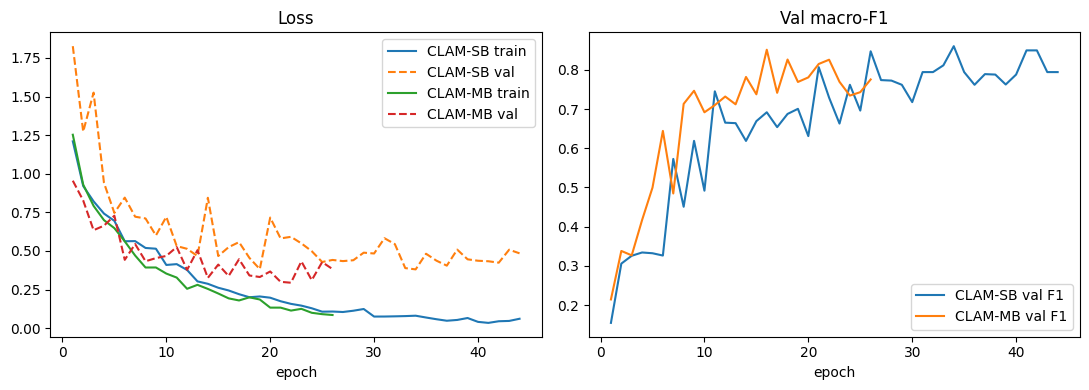

Training complete. Predictions saved to: C:\Users\raphi\Documents\BME515-RCC-Classification\results


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, hist in [('CLAM-SB', sb_hist), ('CLAM-MB', mb_hist)]:
    h = pd.DataFrame(hist)
    axes[0].plot(h.epoch, h.train_loss, label=f'{name} train')
    axes[0].plot(h.epoch, h.val_loss,   label=f'{name} val', linestyle='--')
    axes[1].plot(h.epoch, h.val_f1,     label=f'{name} val F1')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].set_title('Val macro-F1'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'training_curves.png', dpi=150)
plt.show()

print('Training complete. Predictions saved to:', RESULT_DIR)